# Medidas Finales - Análisis de Histéresis Magnética

Este notebook analiza y grafica los datos de medidas VSM (Vibrating Sample Magnetometer) de muestras FeCoNiBSi (aleaciones metálicas amorfas).

## 1. Fundamentos Teóricos

### 1.1 Histéresis Magnética

La **histéresis magnética** es un fenómeno característico de los materiales ferromagnéticos, donde la magnetización $M$ de un material no depende únicamente del campo magnético aplicado $H$, sino también de su historia magnética previa.

Cuando un material ferromagnético es sometido a un campo magnético externo cíclico, se observa una curva cerrada llamada **ciclo de histéresis**. Esta curva se caracteriza por:

- **Magnetización de saturación** ($M_s$): Valor máximo de magnetización alcanzable cuando todos los momentos magnéticos están alineados.
- **Magnetización remanente** ($M_r$): Magnetización residual cuando el campo aplicado es cero.
- **Campo coercitivo** ($H_c$): Campo magnético necesario para reducir la magnetización a cero.

### 1.2 Materiales Amorfos FeCoNiBSi

Las aleaciones amorfas de FeCoNiBSi son materiales **magnéticamente blandos** que presentan:
- Baja coercitividad ($H_c$ pequeño)
- Alta permeabilidad magnética
- Bajas pérdidas por histéresis

Estas propiedades los hacen ideales para aplicaciones en transformadores, sensores magnéticos y dispositivos de almacenamiento.

### 1.3 Magnetómetro de Muestra Vibrante (VSM)

El VSM mide el momento magnético $m$ de una muestra haciéndola vibrar en presencia de un campo magnético uniforme. La muestra oscilante induce una señal de voltaje en bobinas de detección, proporcional al momento magnético:

$$V_{señal} \propto m \cdot \omega \cdot A$$

donde $\omega$ es la frecuencia de vibración y $A$ es la amplitud.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

## 2. Metodología del Análisis

### 2.1 Estructura de los Datos

Los archivos `.DAT` del VSM contienen múltiples columnas de información. Para este análisis, las variables principales son:

| Variable | Símbolo | Unidad | Descripción |
|----------|---------|--------|-------------|
| Campo Magnético | $H$ | Oe (Oersted) | Campo externo aplicado |
| Momento Magnético | $m$ | emu | Momento magnético de la muestra |
| Error Estándar | $\sigma_m$ | emu | Incertidumbre en la medida del momento |

### 2.2 Corrección por Ruido de Fondo

El sistema de medición presenta una señal de ruido de fondo que debe ser sustraída de las medidas. Si $m_{medido}(H)$ es el momento medido y $m_{ruido}(H)$ es la señal de ruido:

$$m_{corregido}(H) = m_{medido}(H) - m_{ruido}(H)$$

El archivo `ruido.dat` contiene la medida de esta señal de fondo realizada en las mismas condiciones experimentales.

## Cargar archivos .DAT de la carpeta Medidas_final

In [2]:
# Ruta a la carpeta con los datos
carpeta = 'Medidas_final'

# Buscar todos los archivos .DAT (excluyendo ruido.dat)
todos_archivos = glob.glob(os.path.join(carpeta, '*.DAT')) + glob.glob(os.path.join(carpeta, '*.dat'))
archivos_dat = [f for f in todos_archivos if 'ruido' not in os.path.basename(f).lower()]

# Verificar si existe el archivo de ruido
archivo_ruido = None
for f in todos_archivos:
    if 'ruido' in os.path.basename(f).lower():
        archivo_ruido = f
        break

print(f"Archivos de medidas encontrados: {len(archivos_dat)}")
for archivo in archivos_dat:
    print(f"  - {os.path.basename(archivo)}")

if archivo_ruido:
    print(f"\n✓ Archivo de ruido encontrado: {os.path.basename(archivo_ruido)}")
else:
    print(f"\n⚠ Archivo de ruido (ruido.dat) no encontrado - las medidas no serán corregidas")

Archivos de medidas encontrados: 5
  - FECONIBSI-M4-0-MVSH-300K.DAT
  - FECONIBSI-M1-45-MVSH-300K.DAT
  - FECONIBSI-M8-15-MVSH-300K.DAT
  - FECONIBSI-M4-15-MVSH-300K.DAT
  - FECONIBSI-M8-30-MVSH-300K.DAT

✓ Archivo de ruido encontrado: ruido.DAT


### 2.3 Propagación de Errores

Al restar la señal de ruido, el error se propaga mediante **suma en cuadratura**. Si $\sigma_{medida}$ es el error de la medida y $\sigma_{ruido}$ es el error del ruido:

$$\sigma_{corregido} = \sqrt{\sigma_{medida}^2 + \sigma_{ruido}^2}$$

Esta fórmula asume que los errores son independientes y siguen una distribución normal. La interpolación del ruido a los valores de campo de cada medida se realiza mediante interpolación lineal.

### 2.4 Proceso de Análisis

El análisis sigue estos pasos:
1. **Carga de datos**: Lectura de archivos `.DAT` excluyendo el archivo de ruido
2. **Carga del ruido**: Lectura del archivo `ruido.dat` si está disponible
3. **Interpolación**: Ajuste de los puntos de ruido a los valores de campo de cada medida
4. **Corrección**: Sustracción del ruido y propagación de errores
5. **Visualización**: Generación de gráficas con barras de error

In [3]:
def leer_archivo_vsm(filepath):
    """
    Lee un archivo .DAT de VSM y extrae los datos relevantes.
    Retorna un DataFrame con Campo Magnético (Oe), Momento (emu) y Error estándar.
    """
    # Encontrar la línea donde comienzan los datos (después de [Data])
    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()
    
    # Buscar la línea de inicio de datos
    data_start = 0
    for i, line in enumerate(lines):
        if '[Data]' in line:
            data_start = i + 1  # La siguiente línea es el header
            break
    
    # Leer los datos saltando las líneas del header
    df = pd.read_csv(filepath, skiprows=data_start, encoding='latin-1')
    
    # Extraer las columnas de interés
    columnas = df.columns.tolist()
    
    # Buscar las columnas por nombre parcial
    campo_col = [col for col in columnas if 'Magnetic Field' in col][0]
    momento_col = [col for col in columnas if col.strip() == 'Moment (emu)'][0]
    temperature_col = [col for col in columnas if 'Temperature' in col][0]
    pressure_col = [col for col in columnas if 'Pressure (Torr)' in col][0]
    m_std_err_col = [col for col in columnas if 'M. Std. Err. (emu)' in col][0]
    
    # Crear DataFrame limpio
    df_clean = df[[campo_col, momento_col, temperature_col, pressure_col, m_std_err_col]].copy()
    df_clean.columns = ['Campo (Oe)', 'Momento (emu)', 'Temperature (K)', 'Pressure (Torr)', 'Error (emu)']
    
    # Eliminar filas con valores NaN
    df_clean = df_clean.dropna()
    
    # Convertir a numérico
    df_clean['Campo (Oe)'] = pd.to_numeric(df_clean['Campo (Oe)'], errors='coerce')
    df_clean['Momento (emu)'] = pd.to_numeric(df_clean['Momento (emu)'], errors='coerce')
    df_clean['Error (emu)'] = pd.to_numeric(df_clean['Error (emu)'], errors='coerce')
    df_clean = df_clean.dropna()
    
    return df_clean

# Leer archivo de ruido si existe
ruido_df = None
if archivo_ruido:
    try:
        ruido_df = leer_archivo_vsm(archivo_ruido)
        print(f"✓ Ruido cargado: {len(ruido_df)} puntos de datos")
        print(f"  Momento de ruido promedio: {ruido_df['Momento (emu)'].mean():.6e} emu")
        print(f"  Error de ruido promedio:   {ruido_df['Error (emu)'].mean():.6e} emu")
    except Exception as e:
        print(f"✗ Error leyendo archivo de ruido: {e}")

# Función para interpolar y restar ruido con propagación de errores
def restar_ruido(df_medida, df_ruido):
    """
    Interpola los valores de ruido a los campos de la medida y los resta.
    Propaga el error usando suma en cuadratura: σ_total = √(σ_medida² + σ_ruido²)
    """
    if df_ruido is None:
        return df_medida
    
    # Interpolar ruido a los valores de campo de la medida
    ruido_interpolado = np.interp(
        df_medida['Campo (Oe)'].values,
        df_ruido['Campo (Oe)'].values,
        df_ruido['Momento (emu)'].values
    )
    
    # Interpolar error del ruido
    error_ruido_interpolado = np.interp(
        df_medida['Campo (Oe)'].values,
        df_ruido['Campo (Oe)'].values,
        df_ruido['Error (emu)'].values
    )
    
    # Crear copia y restar ruido
    df_corregido = df_medida.copy()
    df_corregido['Momento (emu)'] = df_medida['Momento (emu)'] - ruido_interpolado
    
    # Propagar error: σ_total = √(σ_medida² + σ_ruido²)
    df_corregido['Error (emu)'] = np.sqrt(
        df_medida['Error (emu)'].values**2 + error_ruido_interpolado**2
    )
    
    return df_corregido

# Leer todos los archivos de medidas
datos = {}
datos_sin_corregir = {}  # Guardar también los datos originales para comparar

for archivo in archivos_dat:
    nombre = os.path.basename(archivo).replace('.DAT', '').replace('.dat', '')
    try:
        df_original = leer_archivo_vsm(archivo)
        datos_sin_corregir[nombre] = df_original
        
        # Aplicar corrección de ruido si está disponible
        if ruido_df is not None:
            df_corregido = restar_ruido(df_original, ruido_df)
            datos[nombre] = df_corregido
            print(f"✓ {nombre}: {len(df_corregido)} puntos (corregido por ruido)")
        else:
            datos[nombre] = df_original
            print(f"✓ {nombre}: {len(df_original)} puntos (sin corrección de ruido)")
            
    except Exception as e:
        print(f"✗ Error leyendo {nombre}: {e}")

✓ Ruido cargado: 28 puntos de datos
  Momento de ruido promedio: 3.461183e-06 emu
  Error de ruido promedio:   4.774319e-07 emu
✓ FECONIBSI-M4-0-MVSH-300K: 33 puntos (corregido por ruido)
✓ FECONIBSI-M1-45-MVSH-300K: 40 puntos (corregido por ruido)
✓ FECONIBSI-M8-15-MVSH-300K: 35 puntos (corregido por ruido)
✓ FECONIBSI-M4-15-MVSH-300K: 34 puntos (corregido por ruido)
✓ FECONIBSI-M8-30-MVSH-300K: 33 puntos (corregido por ruido)


## 3. Visualización de las Curvas de Histéresis

### 3.1 Curva M vs H

La representación fundamental del comportamiento magnético es la curva de **momento magnético** $m$ (o magnetización $M$) en función del **campo aplicado** $H$. 

En un ciclo de histéresis típico:
- La curva superior corresponde al proceso de **desmagnetización** (campo decreciente)
- La curva inferior corresponde al proceso de **magnetización** (campo creciente)

El área encerrada por el ciclo de histéresis representa la **energía disipada** por ciclo:

$$W = \oint H \, dM$$

Para materiales magnéticamente blandos como FeCoNiBSi, esta área es pequeña, indicando bajas pérdidas energéticas.

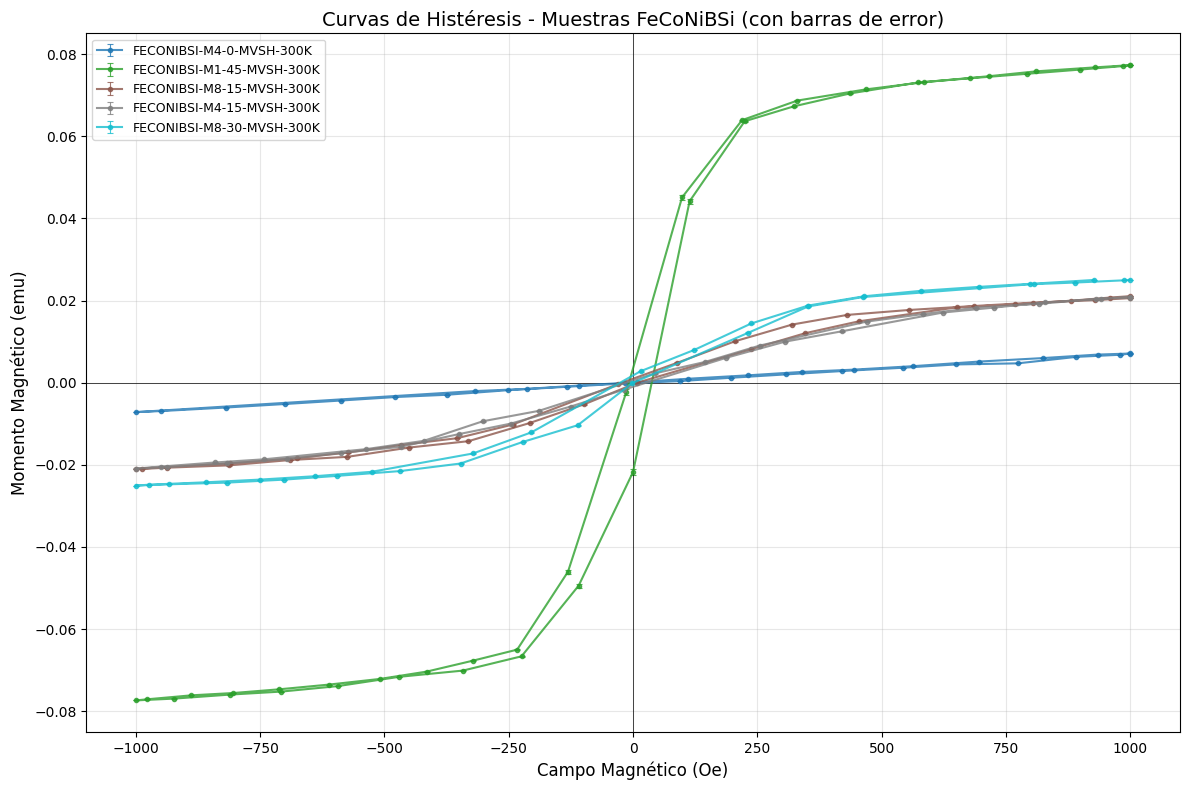

In [4]:
# Graficar todas las curvas de histéresis en un solo gráfico con barras de error
fig, ax = plt.subplots(figsize=(12, 8))

colores = plt.cm.tab10(np.linspace(0, 1, len(datos)))

for (nombre, df), color in zip(datos.items(), colores):
    ax.errorbar(df['Campo (Oe)'], df['Momento (emu)'], 
                yerr=df['Error (emu)'],
                label=nombre, color=color, linewidth=1.5, marker='o', markersize=3,
                capsize=2, capthick=0.8, elinewidth=0.8, alpha=0.8)

ax.set_xlabel('Campo Magnético (Oe)', fontsize=12)
ax.set_ylabel('Momento Magnético (emu)', fontsize=12)
ax.set_title('Curvas de Histéresis - Muestras FeCoNiBSi (con barras de error)', fontsize=14)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

### 3.2 Representación con Barras de Error

Las barras de error en las gráficas representan la incertidumbre estándar $\sigma_m$ en cada punto de medida. Visualmente:
- Una barra de error grande indica mayor incertidumbre en ese punto
- Las barras tienden a ser mayores cerca del campo coercitivo donde la pendiente $dM/dH$ es máxima

La inclusión de barras de error permite evaluar la **significancia estadística** de las diferencias entre muestras y la calidad de las medidas.

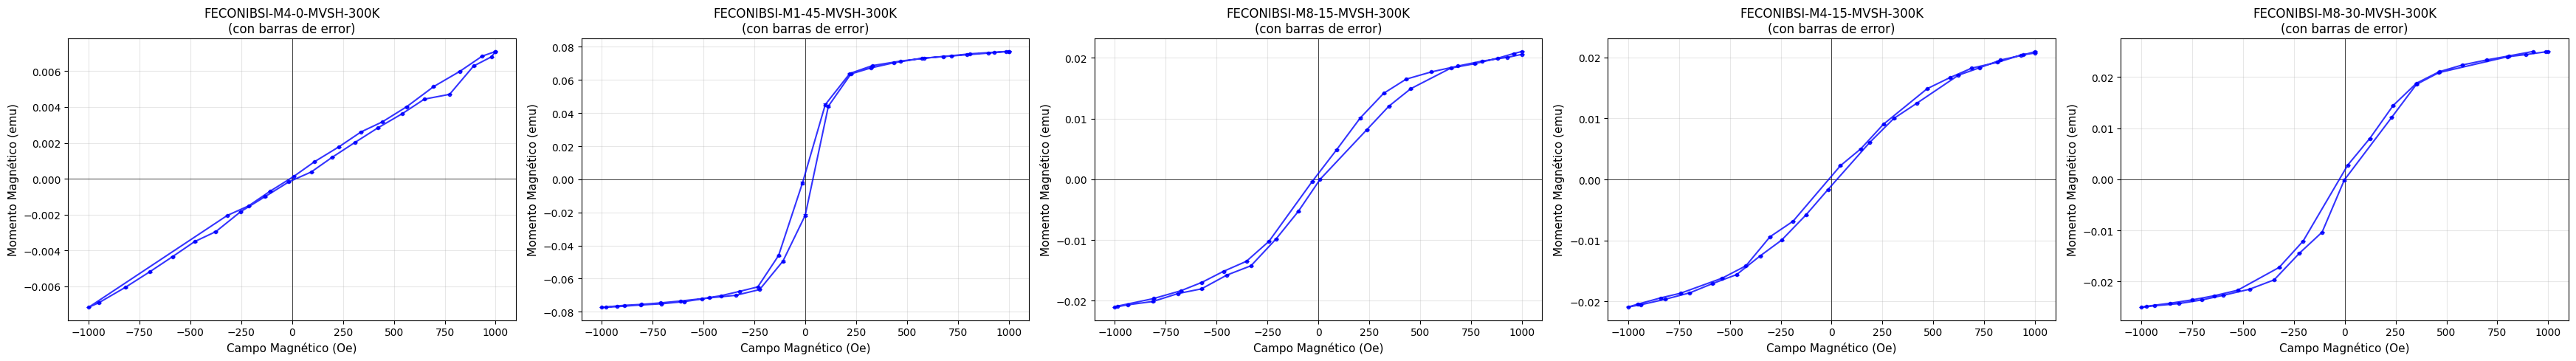

In [5]:
# Graficar cada curva de histéresis en gráficos individuales con barras de error
n_graficos = len(datos)
fig, axes = plt.subplots(1, n_graficos, figsize=(7*n_graficos, 5))

if n_graficos == 1:
    axes = [axes]

for ax, (nombre, df) in zip(axes, datos.items()):
    ax.errorbar(df['Campo (Oe)'], df['Momento (emu)'], 
                yerr=df['Error (emu)'],
                color='blue', linewidth=1.5, marker='o', markersize=3,
                capsize=2, capthick=0.8, elinewidth=0.8, alpha=0.8)
    ax.set_xlabel('Campo Magnético (Oe)', fontsize=11)
    ax.set_ylabel('Momento Magnético (emu)', fontsize=11)
    ax.set_title(f'{nombre}\n(con barras de error)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## 4. Magnetización Volumétrica

### 4.1 Conversión de Momento a Magnetización

El **momento magnético** $m$ medido por el VSM depende del tamaño de la muestra. Para comparar muestras de diferentes dimensiones, se calcula la **magnetización** $M$ (momento por unidad de volumen):

$$M = \frac{m}{V}$$

donde $V$ es el volumen de la muestra en cm³.

### 4.2 Cálculo del Volumen

Las muestras tienen geometría rectangular con dimensiones especificadas en los archivos de datos (largo × ancho × espesor en mm). El volumen se calcula como:

$$V_{mm^3} = l \times w \times t$$

$$V_{cm^3} = \frac{V_{mm^3}}{1000}$$

### 4.3 Propagación del Error en la Magnetización

Al dividir el momento por el volumen (constante), el error se propaga linealmente:

$$\sigma_M = \frac{\sigma_m}{V}$$

Las unidades resultantes son **emu/cm³**, que pueden convertirse a unidades SI (A/m) multiplicando por 1000.

FECONIBSI-M4-0-MVSH-300K: Volumen = 0.1008 mm³ = 0.000101 cm³
FECONIBSI-M1-45-MVSH-300K: Volumen = 0.2146 mm³ = 0.000215 cm³
FECONIBSI-M8-15-MVSH-300K: Volumen = 0.0702 mm³ = 0.000070 cm³
FECONIBSI-M4-15-MVSH-300K: Volumen = 0.1008 mm³ = 0.000101 cm³
FECONIBSI-M8-30-MVSH-300K: Volumen = 0.0702 mm³ = 0.000070 cm³


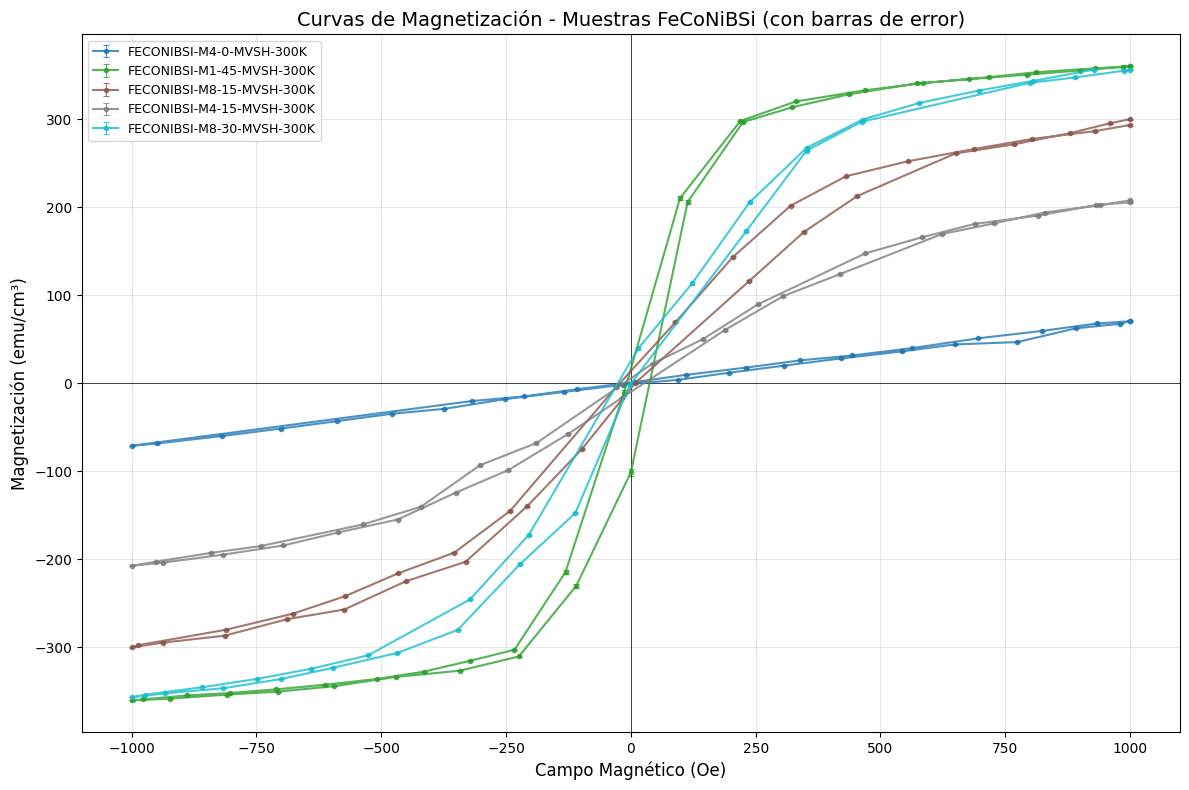

In [6]:
# Graficar curvas divididas por el volumen de la muestra (Magnetización)
# La información de las dimensiones se encuentra en la línea 24 de cada archivo .dat
# Estructura: "INFO,1.35 mm x 1.3 mm x 0.04 mm,SAMPLE_SIZE"

for nombre, df in datos.items():
    archivo = os.path.join(carpeta, f"{nombre}.DAT")
    with open(archivo, 'r', encoding='latin-1') as f:
        lines = f.readlines()
    info_line = lines[23]  # Línea 24 (índice 23)
    dimensiones_str = info_line.split(',')[1].strip()  # Extraer la parte de dimensiones
    dimensiones = dimensiones_str.split(' x ')
    dimensiones_mm = [float(dim.split(' ')[0]) for dim in dimensiones]  # Convertir a float
    volumen_mm3 = np.prod(dimensiones_mm)  # Volumen en mm^3
    volumen_cm3 = volumen_mm3 / 1000  # Convertir a cm^3

    # Dividir el momento y el error por el volumen
    df['Magnetización (emu/cm³)'] = df['Momento (emu)'] / volumen_cm3
    df['Error Magnetización (emu/cm³)'] = df['Error (emu)'] / volumen_cm3
    datos[nombre] = df  # Actualizar el DataFrame en el diccionario
    print(f"{nombre}: Volumen = {volumen_mm3:.4f} mm³ = {volumen_cm3:.6f} cm³")

# Graficar todas las curvas de magnetización en un solo gráfico con barras de error
fig, ax = plt.subplots(figsize=(12, 8))
colores = plt.cm.tab10(np.linspace(0, 1, len(datos)))

for (nombre, df), color in zip(datos.items(), colores):
    ax.errorbar(df['Campo (Oe)'], df['Magnetización (emu/cm³)'], 
                yerr=df['Error Magnetización (emu/cm³)'],
                label=nombre, color=color, linewidth=1.5, marker='o', markersize=3,
                capsize=2, capthick=0.8, elinewidth=0.8, alpha=0.8)

ax.set_xlabel('Campo Magnético (Oe)', fontsize=12)
ax.set_ylabel('Magnetización (emu/cm³)', fontsize=12)
ax.set_title('Curvas de Magnetización - Muestras FeCoNiBSi (con barras de error)', fontsize=14)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

FECONIBSI-M4-0-MVSH-300K: Volumen = 0.1008 mm³ = 0.000101 cm³
FECONIBSI-M1-45-MVSH-300K: Volumen = 0.2146 mm³ = 0.000215 cm³
FECONIBSI-M8-15-MVSH-300K: Volumen = 0.0702 mm³ = 0.000070 cm³
FECONIBSI-M4-15-MVSH-300K: Volumen = 0.1008 mm³ = 0.000101 cm³
FECONIBSI-M8-30-MVSH-300K: Volumen = 0.0702 mm³ = 0.000070 cm³


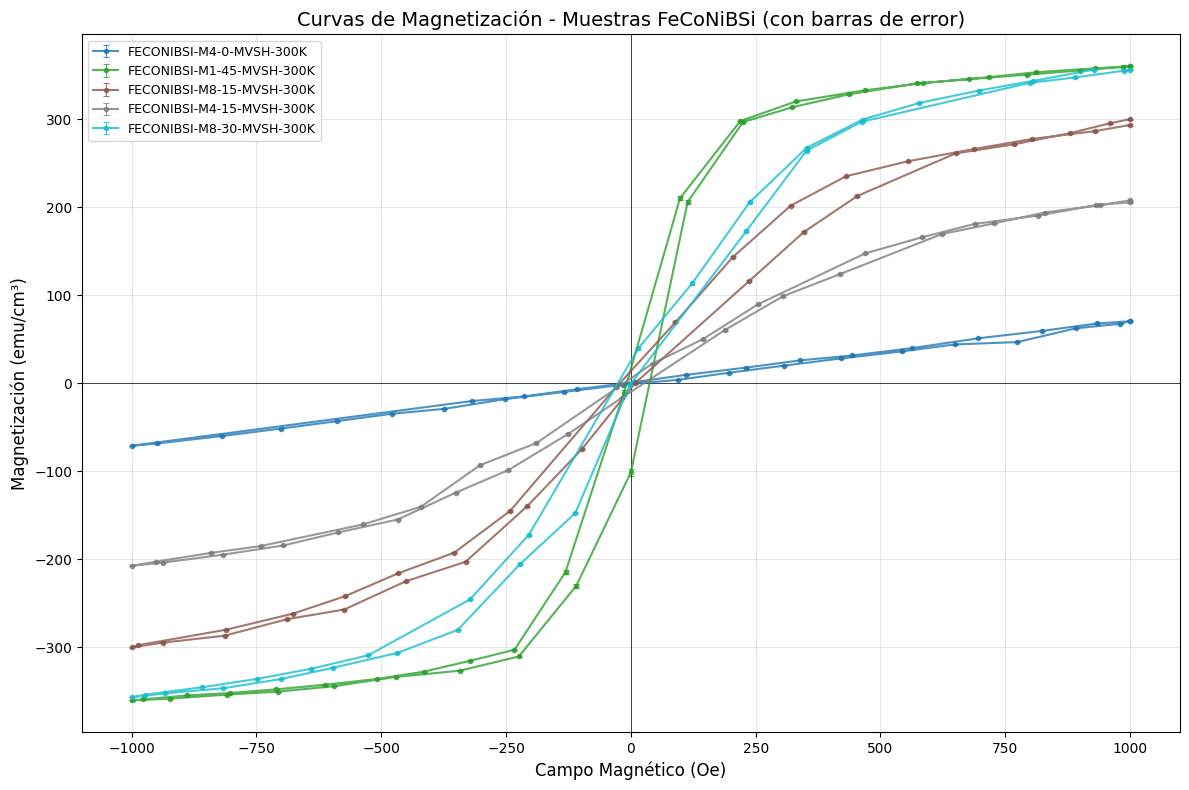

In [7]:
# Graficar curvas divididas por el volumen de la muestra (Magnetización)
# La información de las dimensiones se encuentra en la línea 24 de cada archivo .dat
# Estructura: "INFO,1.35 mm x 1.3 mm x 0.04 mm,SAMPLE_SIZE"

for nombre, df in datos.items():
    archivo = os.path.join(carpeta, f"{nombre}.DAT")
    with open(archivo, 'r', encoding='latin-1') as f:
        lines = f.readlines()
    info_line = lines[23]  # Línea 24 (índice 23)
    dimensiones_str = info_line.split(',')[1].strip()  # Extraer la parte de dimensiones
    dimensiones = dimensiones_str.split(' x ')
    dimensiones_mm = [float(dim.split(' ')[0]) for dim in dimensiones]  # Convertir a float
    volumen_mm3 = np.prod(dimensiones_mm)  # Volumen en mm^3
    volumen_cm3 = volumen_mm3 / 1000  # Convertir a cm^3

    # Dividir el momento y el error por el volumen
    df['Magnetización (emu/cm³)'] = df['Momento (emu)'] / volumen_cm3
    df['Error Magnetización (emu/cm³)'] = df['Error (emu)'] / volumen_cm3
    datos[nombre] = df  # Actualizar el DataFrame en el diccionario
    print(f"{nombre}: Volumen = {volumen_mm3:.4f} mm³ = {volumen_cm3:.6f} cm³")

# Graficar todas las curvas de magnetización en un solo gráfico con barras de error
fig, ax = plt.subplots(figsize=(12, 8))
colores = plt.cm.tab10(np.linspace(0, 1, len(datos)))

for (nombre, df), color in zip(datos.items(), colores):
    ax.errorbar(df['Campo (Oe)'], df['Magnetización (emu/cm³)'], 
                yerr=df['Error Magnetización (emu/cm³)'],
                label=nombre, color=color, linewidth=1.5, marker='o', markersize=3,
                capsize=2, capthick=0.8, elinewidth=0.8, alpha=0.8)

ax.set_xlabel('Campo Magnético (Oe)', fontsize=12)
ax.set_ylabel('Magnetización (emu/cm³)', fontsize=12)
ax.set_title('Curvas de Magnetización - Muestras FeCoNiBSi (con barras de error)', fontsize=14)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## 5. Curvas Normalizadas

### 5.1 Normalización por Magnetización de Saturación

Para comparar el comportamiento magnético de diferentes muestras independientemente de su tamaño o composición exacta, se normaliza el momento por la **magnetización de saturación** $M_s$:

$$m_{norm} = \frac{m}{M_s}$$

Esta representación adimensional permite:
- Comparar la forma de los ciclos de histéresis
- Identificar diferencias en la anisotropía magnética
- Evaluar la "cuadratura" del ciclo (relacionada con la homogeneidad del material)

### 5.2 Propagación del Error Normalizado

El error normalizado se calcula como:

$$\sigma_{norm} = \frac{\sigma_m}{M_s}$$

donde $M_s$ es el valor de referencia de saturación (constante conocida o medida de referencia).

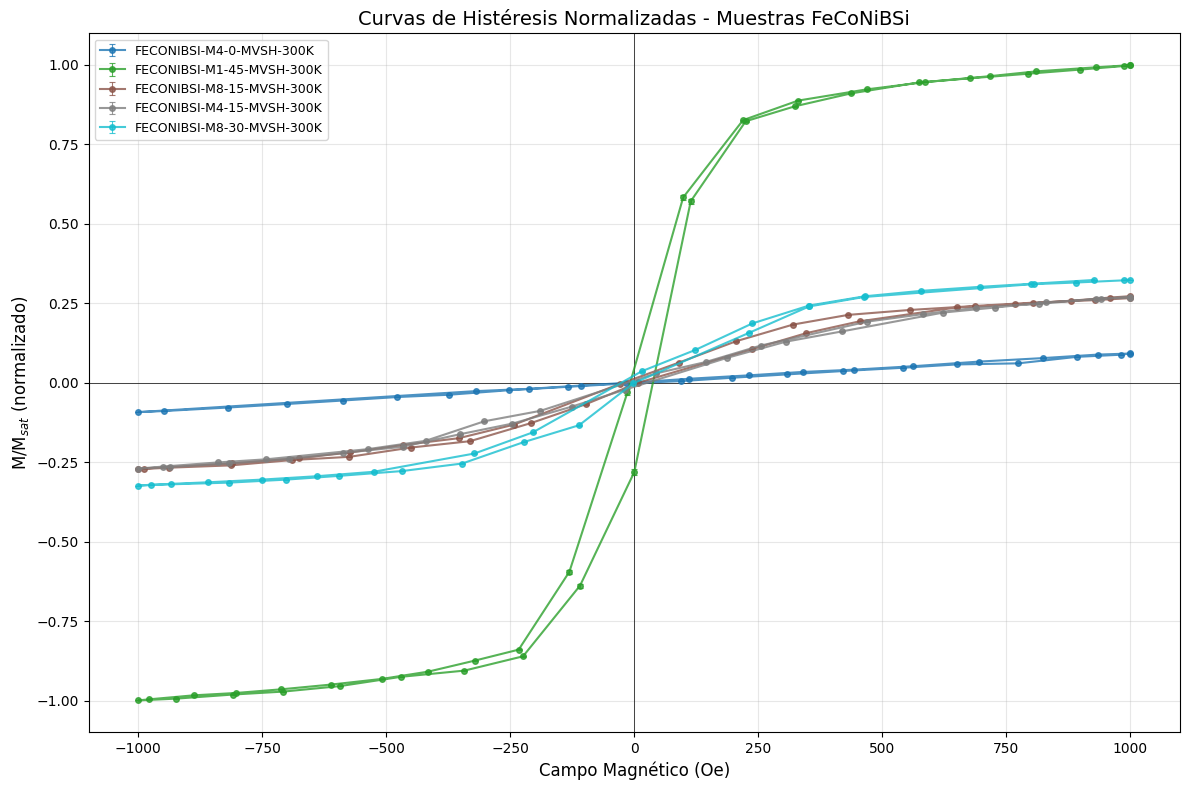

In [8]:
# Graficar curvas de histéresis normalizadas con barras de error
fig, ax = plt.subplots(figsize=(12, 8))

colores = plt.cm.tab10(np.linspace(0, 1, len(datos)))

# Factor de normalización (momento de saturación de referencia)
M_sat_ref = 0.077384

for (nombre, df), color in zip(datos.items(), colores):
    momento_norm = df['Momento (emu)'] / M_sat_ref
    error_norm = df['Error (emu)'] / M_sat_ref
    
    ax.errorbar(df['Campo (Oe)'], momento_norm, 
                yerr=error_norm,
                label=nombre, color=color, linewidth=1.5, marker='o', markersize=4,
                capsize=2, capthick=0.8, elinewidth=0.8, alpha=0.8)

ax.set_xlabel('Campo Magnético (Oe)', fontsize=12)
ax.set_ylabel('M/M$_{sat}$ (normalizado)', fontsize=12)
ax.set_title('Curvas de Histéresis Normalizadas - Muestras FeCoNiBSi', fontsize=14)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## 6. Resumen Estadístico de los Datos

### 6.1 Parámetros Característicos

El análisis estadístico extrae los siguientes parámetros de cada muestra:

| Parámetro | Símbolo | Descripción |
|-----------|---------|-------------|
| Campo máximo | $H_{max}$ | Rango del campo aplicado |
| Momento máximo | $m_{max}$ | Aproximación a la saturación |
| Error promedio | $\bar{\sigma}_m$ | Incertidumbre típica de las medidas |
| Error relativo | $\sigma_m / |m|$ | Precisión relativa de la medida |

### 6.2 Error Relativo

El **error relativo** es una métrica crucial para evaluar la calidad de las medidas:

$$\epsilon_{rel} = \frac{\sigma_m}{|m|} \times 100\%$$

Un error relativo bajo (< 1%) indica medidas de alta precisión. Valores mayores pueden indicar:
- Señal débil cerca del campo coercitivo
- Ruido instrumental significativo
- Inestabilidades térmicas o mecánicas

In [9]:
# Mostrar estadísticas básicas de cada muestra incluyendo errores
print("=" * 90)
print("RESUMEN DE MEDIDAS (con análisis de errores)")
print("=" * 90)

for nombre, df in datos.items():
    print(f"\n{nombre}:")
    print(f"  Rango de Campo:        {df['Campo (Oe)'].min():.2f} a {df['Campo (Oe)'].max():.2f} Oe")
    print(f"  Rango de Momento:      {df['Momento (emu)'].min():.6f} a {df['Momento (emu)'].max():.6f} emu")
    print(f"  Momento máximo:        {df['Momento (emu)'].abs().max():.6f} emu")
    print(f"  Error promedio:        {df['Error (emu)'].mean():.6e} emu")
    print(f"  Error máximo:          {df['Error (emu)'].max():.6e} emu")
    print(f"  Error relativo prom:   {(df['Error (emu)'] / df['Momento (emu)'].abs()).mean() * 100:.2f}%")
    print(f"  Puntos de datos:       {len(df)}")
    
    if 'Magnetización (emu/cm³)' in df.columns:
        print(f"  Magnetización máx:     {df['Magnetización (emu/cm³)'].abs().max():.2f} emu/cm³")
        print(f"  Error Mag. promedio:   {df['Error Magnetización (emu/cm³)'].mean():.2e} emu/cm³")

RESUMEN DE MEDIDAS (con análisis de errores)

FECONIBSI-M4-0-MVSH-300K:
  Rango de Campo:        -999.93 a 999.95 Oe
  Rango de Momento:      -0.007169 a 0.007106 emu
  Momento máximo:        0.007169 emu
  Error promedio:        1.159316e-05 emu
  Error máximo:          1.336661e-05 emu
  Error relativo prom:   1.05%
  Puntos de datos:       33
  Magnetización máx:     71.12 emu/cm³
  Error Mag. promedio:   1.15e-01 emu/cm³

FECONIBSI-M1-45-MVSH-300K:
  Rango de Campo:        -999.89 a 1000.01 Oe
  Rango de Momento:      -0.077356 a 0.077307 emu
  Momento máximo:        0.077356 emu
  Error promedio:        1.184916e-04 emu
  Error máximo:          7.524693e-04 emu
  Error relativo prom:   1.03%
  Puntos de datos:       40
  Magnetización máx:     360.46 emu/cm³
  Error Mag. promedio:   5.52e-01 emu/cm³

FECONIBSI-M8-15-MVSH-300K:
  Rango de Campo:        -1000.02 a 1000.05 Oe
  Rango de Momento:      -0.021076 a 0.021062 emu
  Momento máximo:        0.021076 emu
  Error promedio:    

## 7. Comparación: Datos Originales vs Corregidos por Ruido

### 7.1 Origen del Ruido de Fondo

El ruido de fondo en medidas VSM puede provenir de múltiples fuentes:
- **Portamuestra**: Contribución diamagnética o paramagnética del soporte
- **Electrónica**: Ruido en los amplificadores y sistema de detección
- **Ambiente**: Vibraciones mecánicas y campos magnéticos externos
- **Deriva térmica**: Cambios en la temperatura del sistema

### 7.2 Importancia de la Corrección

La sustracción del ruido es especialmente crítica cuando:
- La señal de la muestra es del mismo orden que el ruido
- Se requiere alta precisión en la determinación de $H_c$ y $M_r$
- Se comparan muestras con momentos magnéticos muy diferentes

### 7.3 Validación de la Corrección

La comparación visual entre datos originales y corregidos permite verificar:
- Que la corrección no introduce artefactos
- Que la forma del ciclo se preserva
- Que el incremento del error propagado es razonable

El error total después de la corrección será siempre mayor que el error original debido a la propagación:

$$\sigma_{total} = \sqrt{\sigma_{medida}^2 + \sigma_{ruido}^2} \geq \sigma_{medida}$$

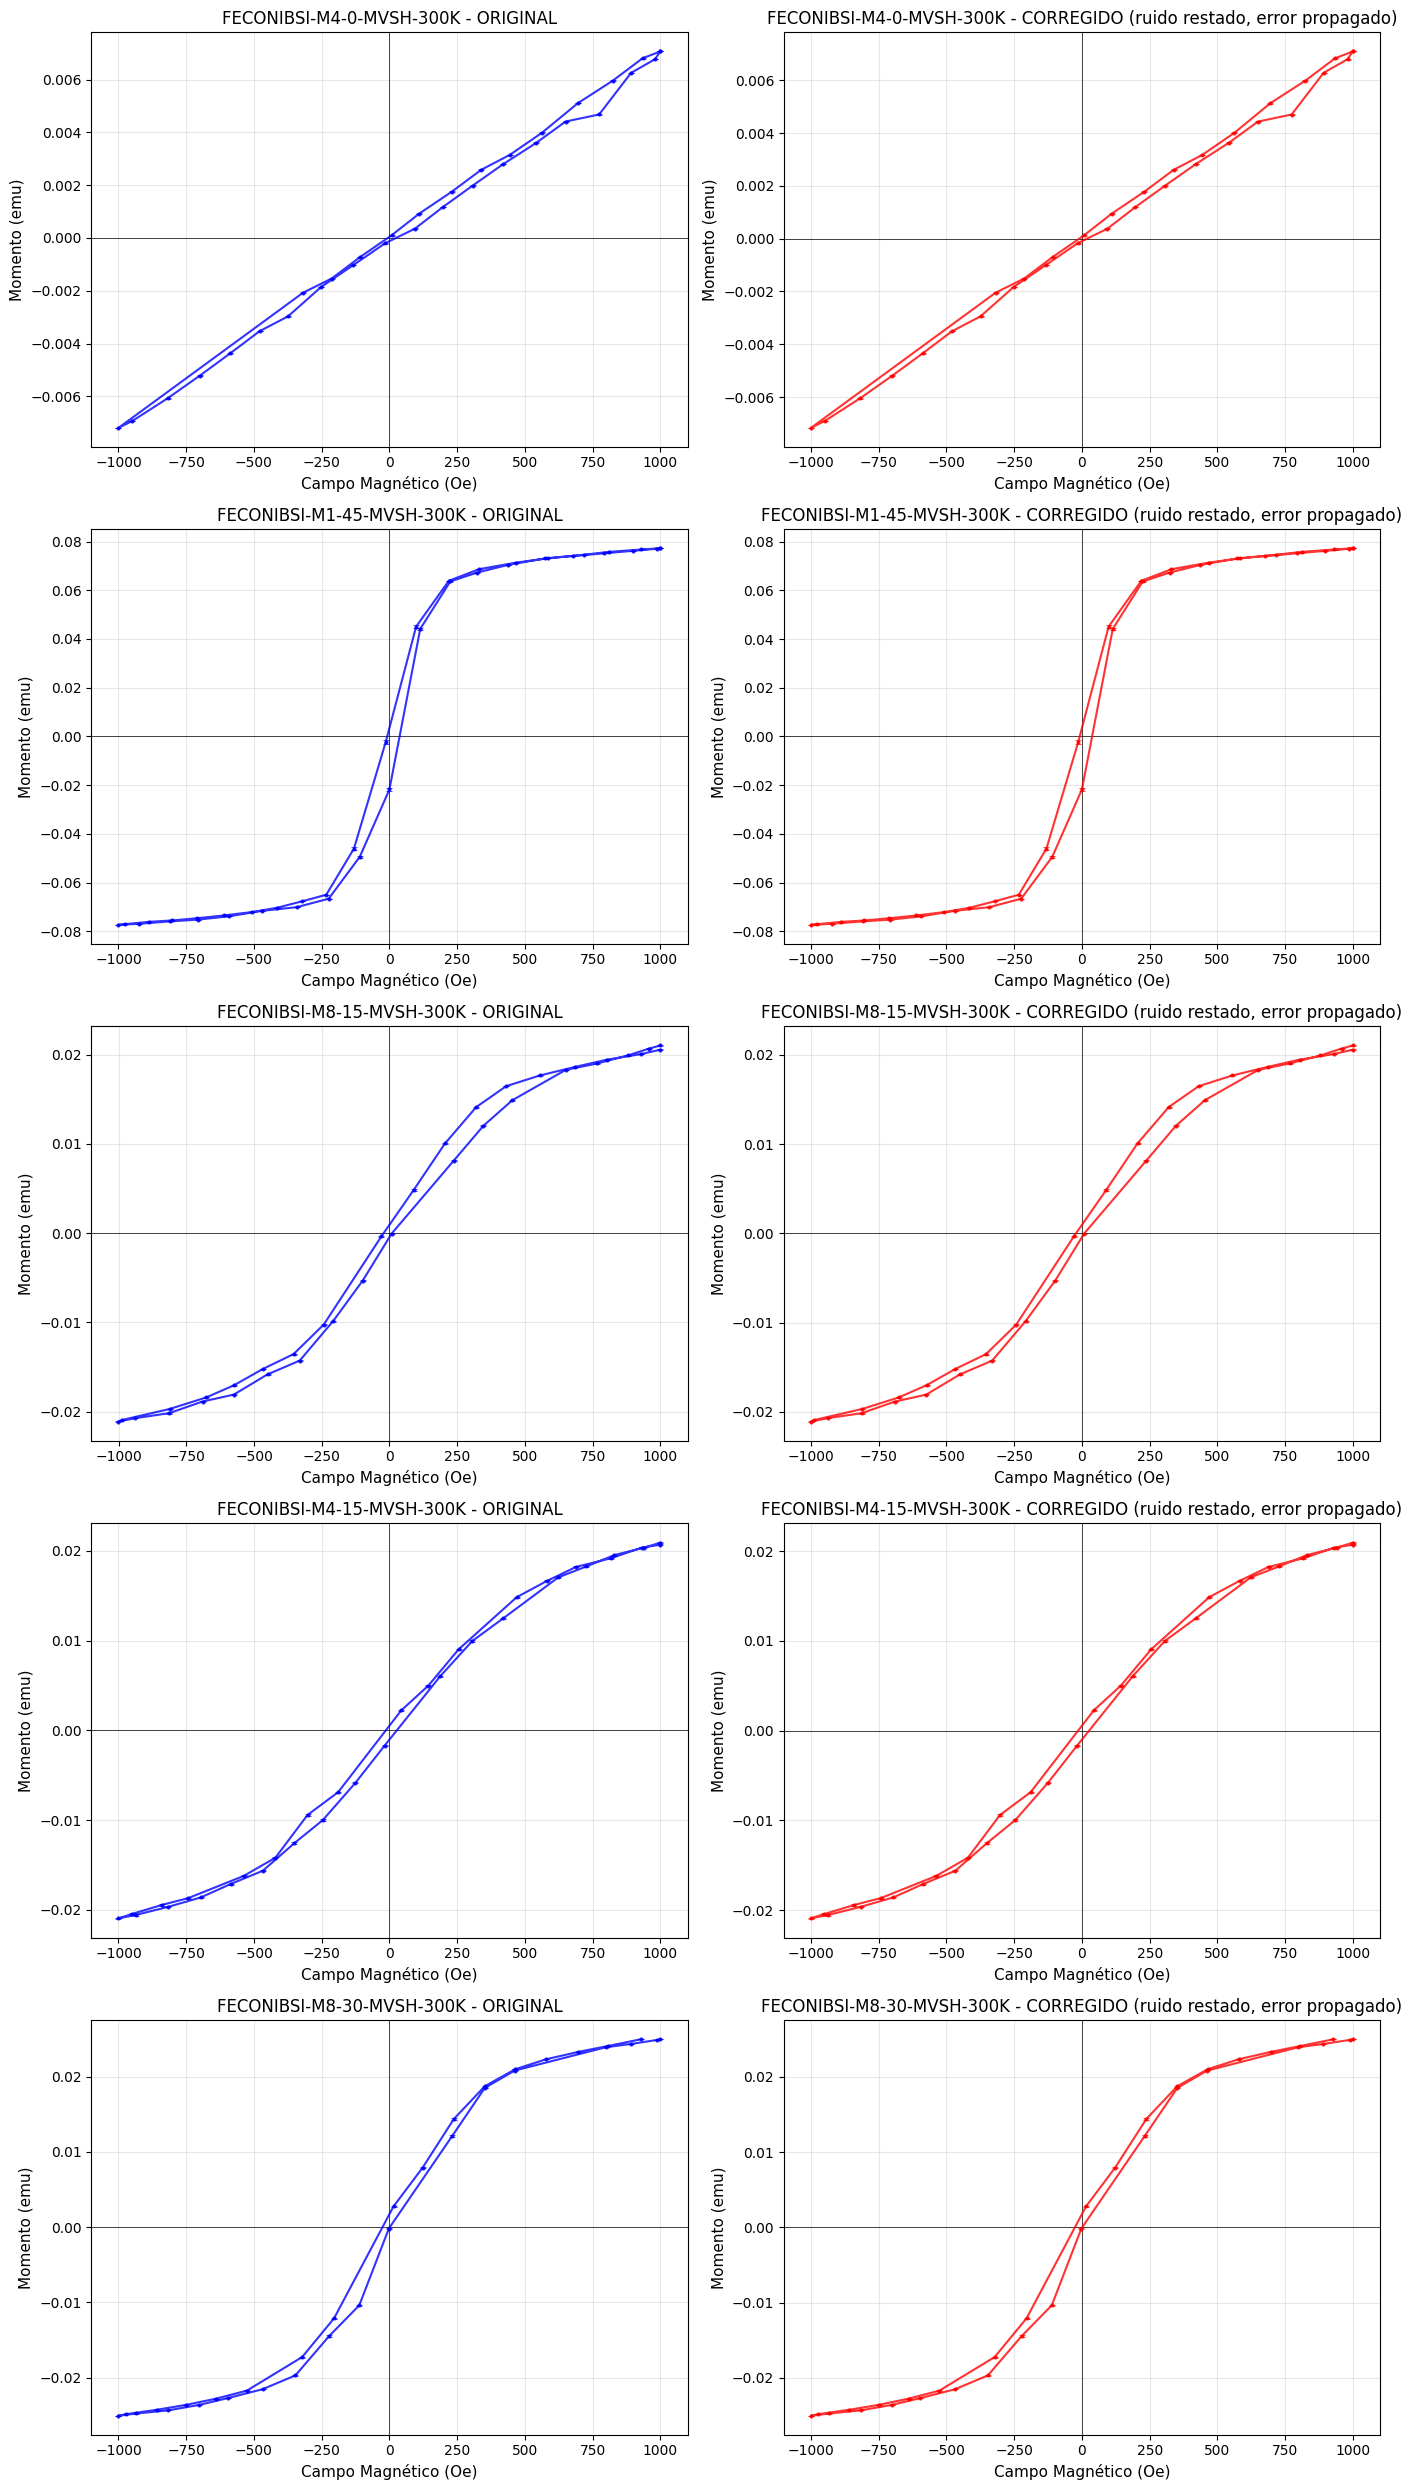

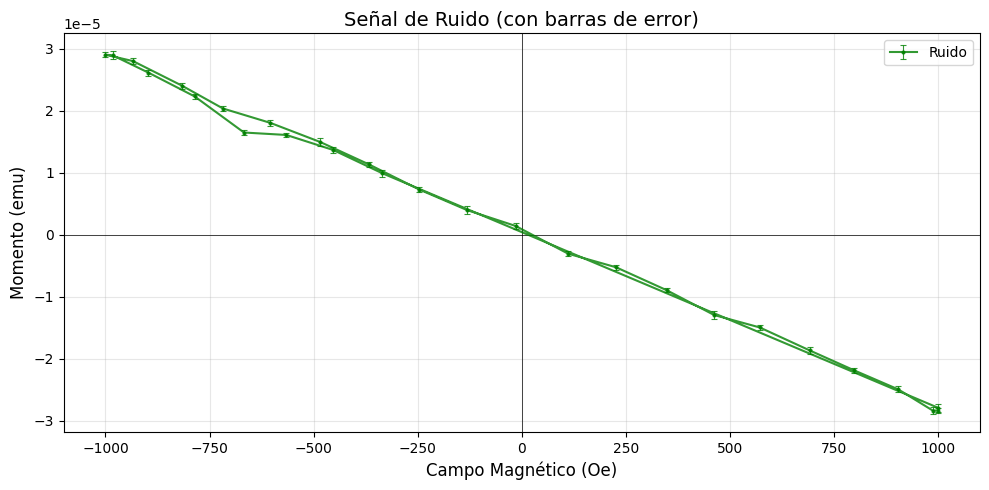


ANÁLISIS DEL RUIDO
Momento de ruido promedio: 3.461183e-06 emu
Momento de ruido máximo:   2.904474e-05 emu
Error de ruido promedio:   4.774319e-07 emu
Error de ruido máximo:     6.333432e-07 emu


In [10]:
# Comparar datos originales vs corregidos (solo si hay corrección de ruido)
if ruido_df is not None:
    n_muestras = len(datos)
    fig, axes = plt.subplots(n_muestras, 2, figsize=(14, 5*n_muestras))
    
    if n_muestras == 1:
        axes = axes.reshape(1, -1)
    
    for idx, nombre in enumerate(datos.keys()):
        # Gráfico original con barras de error
        axes[idx, 0].errorbar(datos_sin_corregir[nombre]['Campo (Oe)'], 
                              datos_sin_corregir[nombre]['Momento (emu)'],
                              yerr=datos_sin_corregir[nombre]['Error (emu)'],
                              color='blue', linewidth=1.5, marker='o', markersize=2,
                              capsize=2, capthick=0.6, elinewidth=0.6, alpha=0.8)
        axes[idx, 0].set_xlabel('Campo Magnético (Oe)', fontsize=11)
        axes[idx, 0].set_ylabel('Momento (emu)', fontsize=11)
        axes[idx, 0].set_title(f'{nombre} - ORIGINAL', fontsize=12)
        axes[idx, 0].grid(True, alpha=0.3)
        axes[idx, 0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        axes[idx, 0].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
        
        # Gráfico corregido con barras de error (incluye propagación)
        axes[idx, 1].errorbar(datos[nombre]['Campo (Oe)'], 
                              datos[nombre]['Momento (emu)'],
                              yerr=datos[nombre]['Error (emu)'],
                              color='red', linewidth=1.5, marker='o', markersize=2,
                              capsize=2, capthick=0.6, elinewidth=0.6, alpha=0.8)
        axes[idx, 1].set_xlabel('Campo Magnético (Oe)', fontsize=11)
        axes[idx, 1].set_ylabel('Momento (emu)', fontsize=11)
        axes[idx, 1].set_title(f'{nombre} - CORREGIDO (ruido restado, error propagado)', fontsize=12)
        axes[idx, 1].grid(True, alpha=0.3)
        axes[idx, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        axes[idx, 1].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar curva de ruido con barras de error
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.errorbar(ruido_df['Campo (Oe)'], ruido_df['Momento (emu)'], 
                yerr=ruido_df['Error (emu)'],
                color='green', linewidth=1.5, marker='o', markersize=2,
                capsize=2, capthick=0.8, elinewidth=0.8, alpha=0.8, label='Ruido')
    ax.set_xlabel('Campo Magnético (Oe)', fontsize=12)
    ax.set_ylabel('Momento (emu)', fontsize=12)
    ax.set_title('Señal de Ruido (con barras de error)', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # Resumen del ruido
    print("\n" + "=" * 60)
    print("ANÁLISIS DEL RUIDO")
    print("=" * 60)
    print(f"Momento de ruido promedio: {ruido_df['Momento (emu)'].mean():.6e} emu")
    print(f"Momento de ruido máximo:   {ruido_df['Momento (emu)'].abs().max():.6e} emu")
    print(f"Error de ruido promedio:   {ruido_df['Error (emu)'].mean():.6e} emu")
    print(f"Error de ruido máximo:     {ruido_df['Error (emu)'].max():.6e} emu")
else:
    print("⚠ No hay archivo de ruido disponible para comparar.")

## 8. Conclusiones y Consideraciones

### 8.1 Interpretación Física

Los ciclos de histéresis de las muestras FeCoNiBSi revelan información sobre:

1. **Anisotropía magnética**: La pendiente del ciclo y su forma indican el tipo de anisotropía (uniaxial, planar, etc.)
2. **Proceso de magnetización**: Dominios magnéticos y su dinámica de pared
3. **Calidad del material**: Defectos y heterogeneidades afectan la forma del ciclo

### 8.2 Consideraciones Experimentales

Para medidas óptimas se recomienda:
- Centrar correctamente la muestra en las bobinas de detección
- Usar tiempos de promediado adecuados para reducir el ruido estadístico
- Realizar medidas de ruido en las mismas condiciones que las muestras
- Verificar la estabilidad térmica durante todo el experimento

### 8.3 Unidades y Conversiones

| Sistema CGS | Sistema SI | Factor de conversión |
|-------------|------------|---------------------|
| Oe (campo) | A/m | 1 Oe = 79.577 A/m |
| emu (momento) | A·m² | 1 emu = 10⁻³ A·m² |
| emu/cm³ (magnetización) | A/m | 1 emu/cm³ = 10³ A/m |